# exploratory analysis

## objective

this notebook explores historical stock performance for eight leading technology companies.

the analysis focuses on:

- cumulative returns
- daily returns
- volatility
- descriptive statistics
- company comparisons

the results provide the foundation for the later discussion of investment risk and market behavior.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stock_data = pd.read_csv(
    "../data/raw/stock_data.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

metadata = pd.read_csv(
    "../data/processed/company_metadata.csv"
)

stock_data.head()

Ticker     PLTR                              AMD                        \
Price      Open High Low Close Volume       Open       High        Low   
Date                                                                     
2020-01-02  NaN  NaN NaN   NaN    NaN  46.860001  49.250000  46.630001   
2020-01-03  NaN  NaN NaN   NaN    NaN  48.029999  49.389999  47.540001   
2020-01-06  NaN  NaN NaN   NaN    NaN  48.020000  48.860001  47.860001   
2020-01-07  NaN  NaN NaN   NaN    NaN  49.349998  49.389999  48.040001   
2020-01-08  NaN  NaN NaN   NaN    NaN  47.849998  48.299999  47.139999   

Ticker                           ...      NVDA                                \
Price           Close    Volume  ...      Open      High       Low     Close   
Date                             ...                                           
2020-01-02  49.099998  80331100  ...  5.934969  5.963804  5.884506  5.963804   
2020-01-03  48.599998  73127400  ...  5.844234  5.912098  5.819375  5.868347   
2020-01-06  48.389999  47934900  ...  5.775127  5.898177  5.749026  5.892956   
2020-01-07  48.250000  58061400  ...  5.921295  6.010040  5.876301  5.964300   
2020-01-08  47.830002  53767000  ...  5.960075  6.016752  5.920053  5.975487   

Ticker                       MSFT                                      \
Price          Volume        Open        High         Low       Close   
Date                                                                    
2020-01-02  237536000  150.090263  151.933540  149.664893  151.829559   
2020-01-03  205384000  149.655425  151.196208  149.409646  149.938995   
2020-01-06  262636000  148.483276  150.392729  147.944465  150.326553   
2020-01-07  314856000  150.600726  150.931563  148.710182  148.955948   
2020-01-08  277108000  150.232049  151.999717  149.305686  151.328568   

Ticker                
Price         Volume  
Date                  
2020-01-02  22622100  
2020-01-03  21116200  
2020-01-06  20813700  
2020-01-07  21634100  
2020-01-08  27746500  

[5 rows x 40 columns]

In [6]:
# adjusted closing prices

close_prices = stock_data.xs("Close", axis=1, level=1)

close_prices.head()

Ticker,PLTR,AMD,META,GOOGL,TSLA,AAPL,NVDA,MSFT
Date,,,,,,,,
2020-01-02,NaN,49.099998,207.953842,67.832504,28.684000,72.271545,5.963804,151.829559
2020-01-03,NaN,48.599998,206.853500,67.477661,29.534000,71.568924,5.868347,149.938995
2020-01-06,NaN,48.389999,210.749298,69.276215,30.102667,72.139191,5.892956,150.326553
2020-01-07,NaN,48.250000,211.205276,69.142395,31.270666,71.799911,5.964300,148.955948
2020-01-08,NaN,47.830002,213.346481,69.634544,32.809334,72.954933,5.975487,151.328568


In [7]:
# calculate daily percentage returns

daily_returns = close_prices.pct_change()

daily_returns.head()

Ticker,PLTR,AMD,META,GOOGL,TSLA,AAPL,NVDA,MSFT
Date,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,-0.010183,-0.005291,-0.005231,0.029633,-0.009722,-0.016006,-0.012452
2020-01-06,NaN,-0.004321,0.018834,0.026654,0.019255,0.007968,0.004194,0.002585
2020-01-07,NaN,-0.002893,0.002164,-0.001932,0.038801,-0.004703,0.012107,-0.009118
2020-01-08,NaN,-0.008705,0.010138,0.007118,0.049205,0.016087,0.001876,0.015928


In [ ]:
summary = pd.DataFrame()

summary["Average Daily Return"] = daily_returns.mean()

summary["Volatility"] = daily_returns.std()

summary["Total Return"] = (
    close_prices.ffill().iloc[-1] /
    close_prices.apply(lambda x: x.dropna().iloc[0]) - 1
)

summary = summary.sort_values(
    "Total Return",
    ascending=False
)

summary

,Average Daily Return,Volatility,Total Return
Ticker,,,
NVDA,0.003015,0.034265,29.019690
TSLA,0.002633,0.042795,10.122577
AMD,0.001481,0.033416,2.656008
MSFT,0.001046,0.019035,2.353582
META,0.001257,0.028020,2.332176
GOOGL,0.000970,0.020558,1.889042
AAPL,0.000963,0.020417,1.878650
PLTR,0.003338,0.045654,NaN


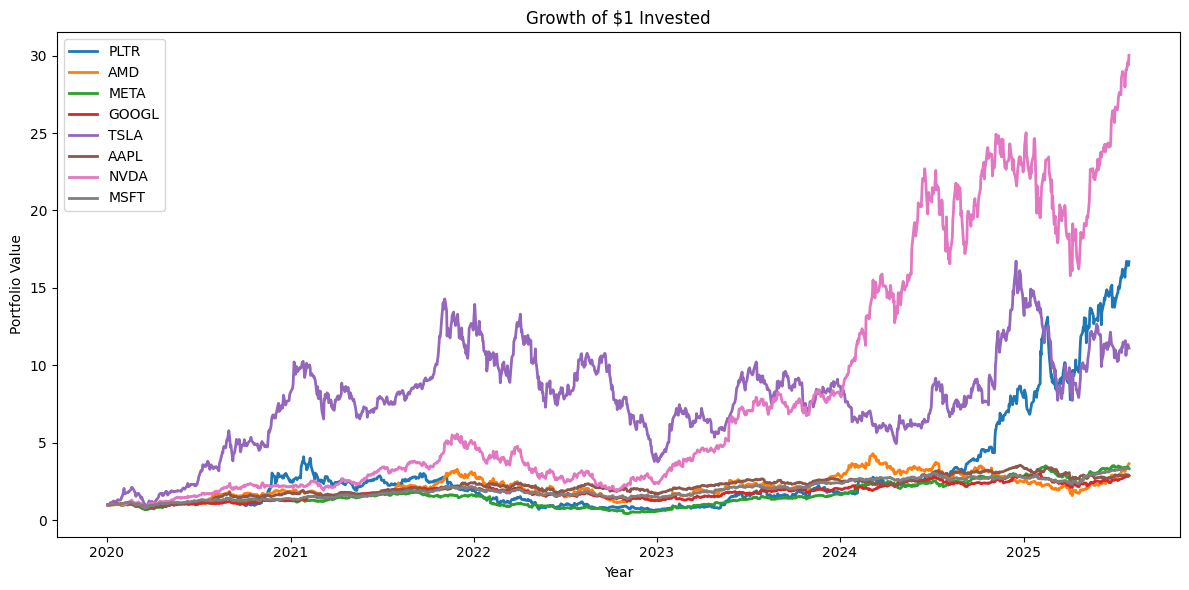

In [9]:
# cumulative returns

cumulative_returns = (1 + daily_returns).cumprod()

plt.figure(figsize=(12,6))

for company in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[company],
        label=company,
        linewidth=2
    )

plt.title("Growth of $1 Invested")
plt.xlabel("Year")
plt.ylabel("Portfolio Value")
plt.legend()

plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values


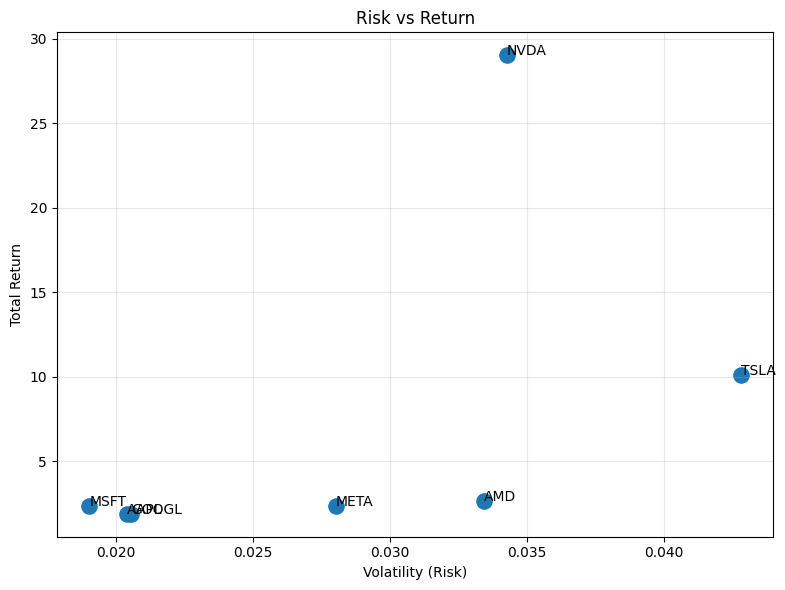

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    summary["Volatility"],
    summary["Total Return"],
    s=120
)

for ticker in summary.index:
    plt.text(
        summary.loc[ticker, "Volatility"],
        summary.loc[ticker, "Total Return"],
        ticker,
        fontsize=10
    )

plt.xlabel("Volatility (Risk)")
plt.ylabel("Total Return")
plt.title("Risk vs Return")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "GOOGL",
    "META",
    "TSLA",
    "AMD",
    "PLTR"
]

In [13]:
drawdowns = {}

for ticker in tickers:
    prices = stock_data[ticker]["Close"].dropna()

    running_max = prices.cummax()

    drawdown = (prices - running_max) / running_max

    drawdowns[ticker] = drawdown.min()

drawdown_df = (
    pd.DataFrame.from_dict(
        drawdowns,
        orient="index",
        columns=["Maximum Drawdown"]
    )
)

drawdown_df = drawdown_df.sort_values("Maximum Drawdown")

drawdown_df

,Maximum Drawdown
PLTR,-0.846154
META,-0.767361
TSLA,-0.736322
NVDA,-0.663351
AMD,-0.654499
GOOGL,-0.443200
MSFT,-0.371485
AAPL,-0.333605
